<a href="https://colab.research.google.com/github/shalineesinghvit12-source/shalineesinghvit12-source/blob/main/AdSales_MLR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sales Prediction

The aim is to build a model which predicts sales based on the money spent on different platforms such as TV, radio, and newspaper for marketing.

In [ ]:
#Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Reading the dataset
from google.colab import files # upload local files to google collab to access it
uploaded = files.upload()
dataset = pd.read_csv("advertising.csv")

Saving advertising.csv to advertising.csv


In [ ]:
dataset.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


# Data Pre-Processing

In [ ]:
dataset.shape

(200, 4)

# Exploratory Data Analysis

**1. Distribution of the target variable**

/tmp/ipython-input-475624845.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['Sales']);


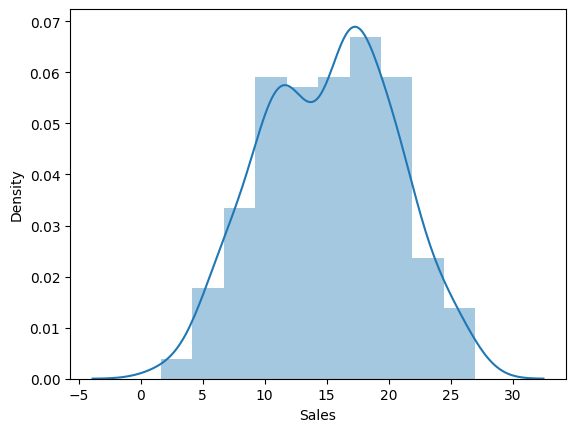

In [ ]:
sns.distplot(dataset['Sales']);

**Conclusion:** It is normally distributed

**2. How Sales are related with other variables**

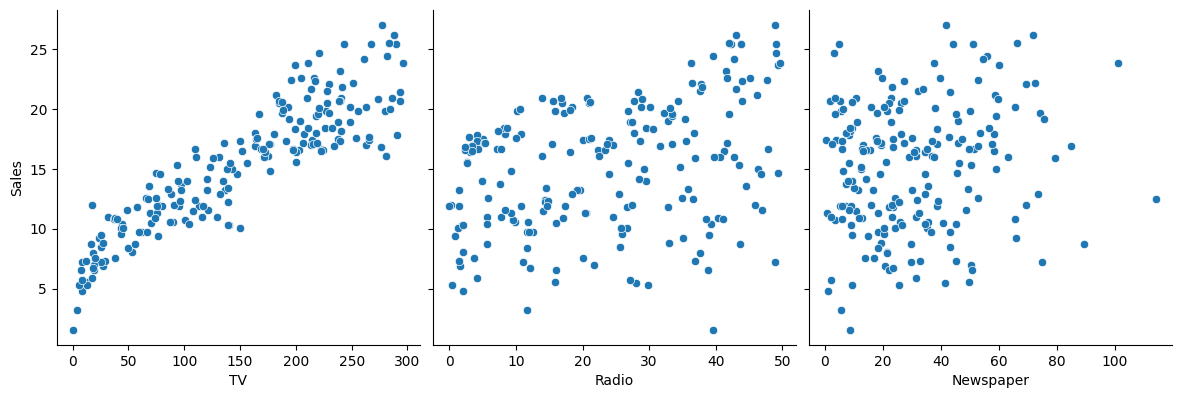

In [ ]:
sns.pairplot(dataset, x_vars=['TV', 'Radio', 'Newspaper'], y_vars='Sales', height=4, aspect=1, kind='scatter')
plt.show()

**Conclusion:** TV is strongly, positively, linearly correlated with the target variable. But the Newspaper feature seems to be uncorrelated

**Multiple Linear Regression**

Multiple linear regression has one y and two or more x variables. It is an extension of Simple Linear regression as it takes more than one predictor variable to predict the response variable.

Multiple Linear Regression is one of the important regression algorithms which models the linear relationship between a single dependent continuous variable and more than one independent variable.

Assumptions for Multiple Linear Regression:
    1. A linear relationship should exist between the Target and predictor variables.
    2. The regression residuals must be normally distributed.
    3. MLR assumes little or no multicollinearity (correlation between the independent variable) in data.
    

    
**Equation:** Sales = β0 + (β1 * TV) + (β2 * Radio) + (β3 * Newspaper)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [ ]:
#Setting the value for X and Y
X = dataset[['TV', 'Radio', 'Newspaper']]
y = dataset['Sales']

In [ ]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.3, random_state=100)

In [ ]:
mlr= LinearRegression()
mlr.fit(X_train, y_train)

In [ ]:
#Printing the model coefficients
print(mlr.intercept_)
# pair the feature names with the coefficients
list(zip(X, mlr.coef_))

In [ ]:
#Predicting the Test set result
y_pred_mlr= mlr.predict(X_test)
#X_pred_mlr= mlr.predict(X_train)

In [ ]:
print("Prediction for test set: {}".format(y_pred_mlr))

In [ ]:
#Actual value and the predicted value
mlr_diff = pd.DataFrame({'Actual value': y_test, 'Predicted value': y_pred_mlr})
mlr_diff

In [ ]:
#Predict for any value
mlr.predict([[56, 55, 67]])

**Conclusion:** The model predicted the Sales of 13.82 in that market

In [ ]:
# print the R-squared value for the model
print('R squared value of the model: {:.2f}'.format(mlr.score(X,y)*100))

**Conclusion:** 90.21% of the data fit the multiple regression model

In [ ]:
# 0 means the model is perfect. Therefore the value should be as close to 0 as possible
meanAbErr = metrics.mean_absolute_error(y_test, y_pred_mlr)
meanSqErr = metrics.mean_squared_error(y_test, y_pred_mlr)


print('Mean Absolute Error:', meanAbErr)
print('Mean Square Error:', meanSqErr)